In [1]:
!date

Fri Sep 18 00:24:24 PDT 2026


In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from concurrent.futures import ProcessPoolExecutor
from statsmodels.stats.multitest import multipletests

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
figdir = f'{projdir}/figures/asm'
outdir = f'{projdir}/results/qc/data/qc16'
!mkdir -p {outdir}
chrom = 'chr20'
def lam(p):
    return np.median(stats.chi2.isf(np.clip(p, 1e-300, 1), 1)) / 0.4549

### per-donor diagnostics from the real chr20 calls

In [4]:
freq = pd.read_csv(f'{projdir}/results/meth_bins/domain_frequency_10kb.tsv.gz', sep='\t', usecols=['chrom', 'bin_start', 'class_pmd'])
freq = freq[freq['chrom'] == chrom]

def donor_qc(f):
    d = pd.read_csv(f, sep='\t', usecols=['sample', 'set', 'start', 'n_reads1', 'n_reads2', 'mu1', 'mu2', 'delta', 'pval', 'method'])
    c = d[d['set'] == 'cpg'].copy()
    if not len(c):
        return None
    c['bin_start'] = (c['start'] // 10000) * 10000
    c = c.merge(freq, on='bin_start', how='left')
    inp = c['class_pmd'].isin(['constitutive', 'common'])
    nev = c['class_pmd'] == 'never'
    z = d[d['set'] == 'zink']
    return {'sample': c['sample'].iloc[0], 'n_tested': len(c), 'lambda_real': lam(c['pval']),
            'lambda_in_domain': lam(c['pval'][inp]) if inp.sum() > 100 else np.nan,
            'lambda_never': lam(c['pval'][nev]) if nev.sum() > 100 else np.nan,
            'frac_p05': (c['pval'] < 0.05).mean(), 'frac_p1e4': (c['pval'] < 1e-4).mean(),
            'frac_delta_pos': (c['delta'] > 0).mean(), 'mean_delta': c['delta'].mean(),
            'median_absdelta': c['delta'].abs().median(), 'median_reads': np.median(c['n_reads1'] + c['n_reads2']),
            'read_imbalance': np.median((c['n_reads1'] - c['n_reads2']).abs() / (c['n_reads1'] + c['n_reads2'])),
            'frac_separation': (c['method'] == 'exact_separation').mean(),
            'zink_n': len(z), 'zink_frac_p1e4': (z['pval'] < 1e-4).mean() if len(z) else np.nan,
            'zink_median_absdelta': z['delta'].abs().median() if len(z) else np.nan}

files = sorted(glob.glob(f'{projdir}/results/asm/calls/*_{chrom}.asm.tsv.gz'))
with ProcessPoolExecutor(10) as ex:
    q = pd.DataFrame([r for r in ex.map(donor_qc, files) if r])
q.shape

(201, 16)

In [5]:
q.head()

,sample,n_tested,lambda_real,lambda_in_domain,lambda_never,frac_p05,frac_p1e4,frac_delta_pos,mean_delta,median_absdelta,median_reads,read_imbalance,frac_separation,zink_n,zink_frac_p1e4,zink_median_absdelta
0,HG00097,49830,0.912492,0.955697,0.801978,0.076560,0.003833,0.512944,0.001476,0.032000,51.0,0.098039,0.000341,12,0.833333,0.706103
1,HG00099,49668,3.309045,3.438563,2.992796,0.320991,0.080072,0.495208,-0.000536,0.043526,58.0,0.090909,0.000825,12,0.833333,0.775801
2,HG00126,49209,0.962873,1.083171,0.777573,0.088785,0.006523,0.485805,-0.002573,0.030810,67.0,0.088235,0.000264,12,0.916667,0.714346
3,HG00128,49961,1.385617,1.364590,1.322207,0.151418,0.016993,0.500130,-0.000605,0.037951,53.0,0.090909,0.000340,12,0.916667,0.759707
4,HG00133,49443,0.994822,1.069457,0.862070,0.094897,0.004955,0.499929,0.000002,0.031896,62.0,0.087719,0.000283,12,0.750000,0.724765


### add the empirical null (C06a: split one haplotype in half), covariates and genome-wide yield

In [6]:
nulls = sorted(glob.glob(f'{projdir}/results/asm/null/*_{chrom}.null_summary.tsv'))
nl = pd.concat([pd.read_csv(f, sep='\t') for f in nulls]) if nulls else pd.DataFrame()
if len(nl):
    nl = nl.groupby('sample').agg(lambda_null=('lambda_null', 'mean'), null_frac_p05=('frac_p05', 'mean'),
                                  null_mean_absdelta=('mean_absdelta', 'mean'),
                                  median_read_sd=('median_read_sd', 'mean')).reset_index()
print(len(nl), 'donors with empirical null so far')

201 donors with empirical null so far


In [7]:
chem = pd.read_csv(f'{projdir}/results/qc/data/supp_seq_qc.csv').set_index('sample_id')['sequencing_chemistry_ont']
sp = pd.read_csv(f'{projdir}/tsv/meta/hprc2_sample_manifest.tsv', sep='\t').set_index('sample_id')['superpopulation']
dm = pd.read_csv(f'{projdir}/results/qc/data/qc13/donor_pmd_expansion_metrics.tsv', sep='\t')[
    ['sample', 'depth_constitutive', 'global_meth', 'mcg_never']]
ds = pd.read_csv(f'{projdir}/results/asm/genome/donor_summary.tsv', sep='\t')[
    ['sample', 'n_tested', 'n_asm', 'frac_asm', 'frac_reads_het', 'frac_reads_kept', 'median_reads']].rename(
    columns={'n_tested': 'gw_n_tested', 'n_asm': 'gw_n_asm', 'median_reads': 'gw_median_reads'})
xist = pd.read_csv(f'{projdir}/results/qc/data/xist_promoter_skew.tsv', sep='\t')[['sample', 'skew']].rename(columns={'skew': 'xist_skew'})
q['chemistry'] = q['sample'].map(chem); q['superpop'] = q['sample'].map(sp)
q = q.merge(dm, on='sample', how='left').merge(ds, on='sample', how='left').merge(xist, on='sample', how='left')
if len(nl):
    q = q.merge(nl, on='sample', how='left')
    q['excess_lambda'] = q['lambda_real'] / q['lambda_null']
q.describe().loc[['mean', 'std', 'min', '50%', 'max']].round(3).T

,mean,std,min,50%,max
n_tested,49574.567,709.017,43221.000,49749.000,49992.000
lambda_real,1.942,1.492,0.812,1.535,13.128
lambda_in_domain,1.920,1.525,0.856,1.504,14.630
lambda_never,1.850,1.368,0.726,1.471,10.216
frac_p05,0.176,0.099,0.059,0.154,0.577
frac_p1e4,0.027,0.041,0.001,0.011,0.293
frac_delta_pos,0.501,0.016,0.454,0.500,0.589
mean_delta,0.000,0.003,-0.009,0.000,0.017
median_absdelta,0.036,0.008,0.024,0.034,0.069
median_reads,62.866,9.138,34.000,62.000,86.000


### is the test itself miscalibrated, or are the haplotype differences real?

       lambda_null  lambda_real  excess_lambda
count      201.000      201.000        201.000
mean         0.669        1.942          2.922
std          0.015        1.492          2.319
min          0.614        0.812          1.211
25%          0.660        1.073          1.613
50%          0.672        1.535          2.302
75%          0.679        2.242          3.365
max          0.707       13.128         20.823


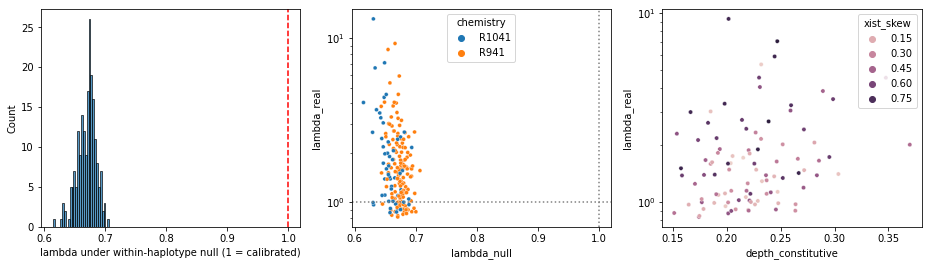

In [8]:
if 'lambda_null' in q:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    sns.histplot(q['lambda_null'].dropna(), bins=30, ax=axes[0]); axes[0].axvline(1, c='r', ls='--')
    axes[0].set_xlabel('lambda under within-haplotype null (1 = calibrated)')
    sns.scatterplot(data=q, x='lambda_null', y='lambda_real', hue='chemistry', s=16, ax=axes[1])
    axes[1].axhline(1, c='gray', ls=':'); axes[1].axvline(1, c='gray', ls=':'); axes[1].set_yscale('log')
    sns.scatterplot(data=q, x='depth_constitutive', y='lambda_real', hue='xist_skew', s=18, ax=axes[2])
    axes[2].set_yscale('log')
    plt.tight_layout(); plt.savefig(f'{figdir}/qc16_calibration.png', dpi=150)
    print(q[['lambda_null', 'lambda_real', 'excess_lambda']].describe().round(3).to_string())

### is the inflation confined to PMDs?

median lambda in-domain 1.50 vs never-PMD 1.47
donors where never-PMD lambda > 1.5: 98 / 201


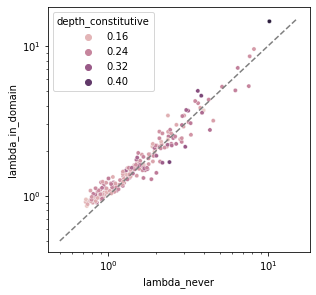

In [9]:
sub = q.dropna(subset=['lambda_in_domain', 'lambda_never'])
print('median lambda in-domain %.2f vs never-PMD %.2f' % (sub['lambda_in_domain'].median(), sub['lambda_never'].median()))
print('donors where never-PMD lambda > 1.5:', (sub['lambda_never'] > 1.5).sum(), '/', len(sub))
fig, ax = plt.subplots(figsize=(4.5, 4.2))
sns.scatterplot(data=sub, x='lambda_never', y='lambda_in_domain', hue='depth_constitutive', s=18, ax=ax)
lim = [0.5, sub[['lambda_never', 'lambda_in_domain']].max().max() * 1.05]
ax.plot(lim, lim, ls='--', c='gray'); ax.set_xscale('log'); ax.set_yscale('log')
plt.tight_layout(); plt.savefig(f'{figdir}/qc16_inflation_in_vs_out_domains.png', dpi=150)

### what predicts the donor-level inflation

In [10]:
d = q.dropna(subset=['lambda_real', 'depth_constitutive'])
terms = ['depth_constitutive', 'xist_skew', 'frac_reads_het', 'median_reads', 'read_imbalance', 'global_meth', 'mcg_never']
rows = []
for t in terms:
    x = d.dropna(subset=[t])
    f0 = smf.ols('np.log(lambda_real) ~ C(chemistry) + C(superpop)', x).fit()
    f1 = smf.ols(f'np.log(lambda_real) ~ C(chemistry) + C(superpop) + {t}', x).fit()
    rows.append({'covariate': t, 'n': len(x), 'partial_r2': (f0.ssr - f1.ssr) / f0.ssr, 'p': f1.pvalues[t]})
pd.DataFrame(rows).round(4)

,covariate,n,partial_r2,p
0,depth_constitutive,201,0.1140,0.0000
1,xist_skew,96,0.1680,0.0001
2,frac_reads_het,201,0.0047,0.3436
3,median_reads,201,0.0290,0.0182
4,read_imbalance,201,0.0210,0.0447
5,global_meth,201,0.0761,0.0001
6,mcg_never,201,0.1736,0.0000


In [11]:
full = smf.ols('np.log(lambda_real) ~ depth_constitutive + xist_skew + C(chemistry) + C(superpop) + median_reads', d.dropna(subset=['xist_skew'])).fit()
print('R2 %.3f' % full.rsquared)
pd.DataFrame({'coef': full.params, 'p': full.pvalues}).round(4)

R2 0.405


,coef,p
Intercept,-1.4393,0.0025
C(chemistry)[T.R941],0.0552,0.6246
C(superpop)[T.AMR],-0.0201,0.8781
C(superpop)[T.EAS],-0.3431,0.0184
C(superpop)[T.EUR],-0.3207,0.0209
C(superpop)[T.SAS],-0.2650,0.0687
depth_constitutive,3.7202,0.0033
xist_skew,0.9355,0.0000
median_reads,0.0132,0.0144


### positive control: Zink imprinted DMRs vs inflation

In [12]:
zk = pd.read_csv(f'{projdir}/results/asm/genome/zink_control.tsv', sep='\t')
zd = zk.groupby('sample').agg(zink_det=('asm', 'mean'), zink_absd=('delta', lambda x: x.abs().mean())).reset_index()
qz = q.merge(zd, on='sample', how='left')
print('corr(zink detection, lambda_real) = %.3f' % qz[['zink_det', 'lambda_real']].corr().iloc[0, 1])
print('corr(zink |delta|, lambda_real)   = %.3f' % qz[['zink_absd', 'lambda_real']].corr().iloc[0, 1])
print(qz.groupby(pd.qcut(qz['lambda_real'], 4))[['zink_det', 'zink_absd', 'frac_asm']].median().round(3).to_string())

corr(zink detection, lambda_real) = -0.125
corr(zink |delta|, lambda_real)   = 0.061
                 zink_det  zink_absd  frac_asm
lambda_real                                   
(0.811, 1.073]      0.430      0.247     0.002
(1.073, 1.535]      0.435      0.250     0.004
(1.535, 2.242]      0.424      0.247     0.011
(2.242, 13.128]     0.432      0.259     0.031


### genomic-control recalibration: how many ASM calls survive per donor

In [13]:
def recal(f):
    d = pd.read_csv(f, sep='\t', usecols=['sample', 'set', 'pval', 'delta'])
    c = d[d['set'] == 'cpg']
    if len(c) < 1000:
        return None
    l = lam(c['pval'])
    chi2 = stats.chi2.isf(np.clip(c['pval'], 1e-300, 1), 1) / max(l, 1.0)
    p_gc = stats.chi2.sf(chi2, 1)
    q_raw = multipletests(c['pval'], method='fdr_bh')[1]
    q_gc = multipletests(p_gc, method='fdr_bh')[1]
    big = c['delta'].abs() >= 0.2
    return {'sample': c['sample'].iloc[0], 'lambda': l,
            'n_sig_raw': int(((q_raw < 0.05) & big).sum()), 'n_sig_gc': int(((q_gc < 0.05) & big).sum())}

with ProcessPoolExecutor(10) as ex:
    rc = pd.DataFrame([r for r in ex.map(recal, files) if r])
rc['ratio'] = rc['n_sig_gc'] / rc['n_sig_raw'].replace(0, np.nan)
print(rc[['lambda', 'n_sig_raw', 'n_sig_gc', 'ratio']].describe().round(3).to_string())
rc.sort_values('lambda', ascending=False).head(10).round(3)

        lambda  n_sig_raw  n_sig_gc    ratio
count  201.000    201.000   201.000  201.000
mean     1.942    719.458   143.796    0.506
std      1.492    828.980   101.607    0.372
min      0.812     12.000     0.000    0.000
25%      1.073    192.000    94.000    0.164
50%      1.535    407.000   135.000    0.488
75%      2.242    879.000   181.000    0.886
max     13.128   5344.000   743.000    1.000


,sample,lambda,n_sig_raw,n_sig_gc,ratio
187,NA20762,13.128,5344,0,0.0
40,HG01150,9.296,3586,0,0.0
72,HG02040,8.538,3398,0,0.0
157,NA18508,7.083,2981,0,0.0
161,NA18608,6.592,3105,0,0.0
131,HG03540,5.885,3373,0,0.0
67,HG01981,5.340,3448,0,0.0
172,NA19159,4.548,2626,0,0.0
98,HG02583,4.540,2163,0,0.0
11,HG00290,4.361,2907,0,0.0


### donor QC flags

In [14]:
qq = q.merge(rc[['sample', 'n_sig_raw', 'n_sig_gc']], on='sample', how='left')
qq['flag_inflated'] = qq['lambda_real'] > 2
qq['flag_null_bad'] = (qq['lambda_null'] > 1.2) if 'lambda_null' in qq else False
qq['flag_low_cov'] = qq['median_reads'] < 20
qq['flag_sign_bias'] = (qq['frac_delta_pos'] - 0.5).abs() > 0.05
qq['flag_any'] = qq[['flag_inflated', 'flag_null_bad', 'flag_low_cov', 'flag_sign_bias']].any(axis=1)
print(qq[['flag_inflated', 'flag_null_bad', 'flag_low_cov', 'flag_sign_bias', 'flag_any']].sum().to_string())
qq.sort_values('lambda_real', ascending=False).head(12)[
    ['sample', 'superpop', 'chemistry', 'lambda_real', 'lambda_null' if 'lambda_null' in qq else 'frac_p05',
     'depth_constitutive', 'xist_skew', 'frac_asm', 'n_sig_raw', 'n_sig_gc']].round(3)

flag_inflated     62
flag_null_bad      0
flag_low_cov       0
flag_sign_bias     1
flag_any          62


,sample,superpop,chemistry,lambda_real,lambda_null,depth_constitutive,xist_skew,frac_asm,n_sig_raw,n_sig_gc
187,NA20762,EUR,R1041,13.128,0.630,0.475,NaN,0.118,5344,0
40,HG01150,AMR,R941,9.296,0.666,0.202,0.778,0.071,3586,0
72,HG02040,EAS,R941,8.538,0.654,0.218,NaN,0.070,3398,0
157,NA18508,AFR,R1041,7.083,0.649,0.247,0.853,0.062,2981,0
161,NA18608,EAS,R1041,6.592,0.633,0.240,NaN,0.066,3105,0
131,HG03540,AFR,R941,5.885,0.673,0.244,0.786,0.071,3373,0
67,HG01981,AMR,R941,5.340,0.658,0.232,0.027,0.070,3448,0
172,NA19159,AFR,R941,4.548,0.671,0.230,0.639,0.050,2626,0
98,HG02583,AFR,R1041,4.540,0.651,0.348,0.425,0.049,2163,0
11,HG00290,EUR,R1041,4.361,0.648,0.364,NaN,0.061,2907,0


In [15]:
qq.to_csv(f'{outdir}/asm_donor_qc_{chrom}.tsv', sep='\t', index=False)
rc.to_csv(f'{outdir}/asm_genomic_control_{chrom}.tsv', sep='\t', index=False)

In [16]:
!date

Fri Sep 18 00:25:16 PDT 2026
